# Hypsometric analysis for relict landslides

In [ ]:
import pip
pip.main(['install','matplotlib-scalebar'])

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sbn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
import pysal

import warnings
warnings.filterwarnings("ignore")

Se importa poligono de area de estudio.

,fid,Area_Km2,Perime_Km,_mean,_min,_max,_range,_mean_1,_min_1,_max_1,codigo,Indices_ma,Indices__1,geometry
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,"POLYGON ((456805.063 868201.875, 456805.063 86..."


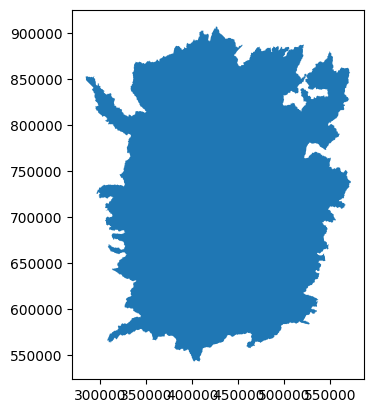

In [2]:
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot()
aoi.head()

### Catchments with chi zonal statistic

In [3]:
chi_cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/subbasins_chi_zonalStatistic.gpkg")
chi_cat.head(2)

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,_chicount,_chimean,_chimedian,_chistdev,_chimin,_chimax,geometry
0,1,0.0,2827.0,120.181924,Quebrada Los San Andreses,0,0.107,0.096501,A,1362.0,10.017347,10.0760,2.848651,4.6349,16.0110,"MULTIPOLYGON (((411860.438 900002.542, 411964...."
1,2,1.0,3161.0,33.492364,Quebrada Sabalito,1,0.334,0.321164,A,365.0,6.036456,5.8155,1.697432,3.2042,9.9998,"MULTIPOLYGON (((505464.576 881616.272, 505673...."


### Catchments with Ks zonal statistical

In [21]:
k_cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/subbasins_Ks_zonalStatistic.gpkg")
k_cat.head(2)

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,_Kscount,_Ksmean,_Ksmedian,_Ksstdev,_Ksmin,_Ksmax,_Ksrange,geometry
0,1,0.0,2827.0,120.181924,Quebrada Los San Andreses,0,0.107,0.096501,A,1863.0,6.202666,3.7448,10.010615,0.040741,69.027,68.986259,"MULTIPOLYGON (((411860.438 900002.542, 411964...."
1,2,1.0,3161.0,33.492364,Quebrada Sabalito,1,0.334,0.321164,A,536.0,2.188858,1.9327,1.201385,1.108800,7.034,5.925200,"MULTIPOLYGON (((505464.576 881616.272, 505673...."


Se importa archivo que se elaboro en QGIS de los movimientos en masa recientes con el valor de lluvia media anual proveniente de CHIRPS, el cual se elaboro inicialmente en Google Earth Engine y luego en QGIS se estimo el valor media para cada cuenca.

In [4]:
catchments=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/hypso3.gpkg")
catchments.head(2)

,OBJECTID,Id,gridcode,Área,hypso_inte,area_curva,Shape_Leng,Shape_Le_1,Shape_Area,Nombre,Lineamient,Densidad,_mean,knickpoint,geometry
0,1,4.0,2827.0,120.181924,0.107,0.096448,59628.024115,59459.370531,1.201791e+08,Quebrada Los San Andreses,294.0,2.446291,2250.332866,E,"MULTIPOLYGON (((411860.438 900002.542, 411964...."
1,2,36.0,3161.0,33.492364,0.334,0.321148,41322.987731,41322.987731,3.349236e+07,Quebrada Sabalito,0.0,0.000000,3457.470653,A,"MULTIPOLYGON (((505464.576 881616.272, 505673...."


In [5]:
catchments.drop(["Id",'gridcode','area_curva','Shape_Leng','Shape_Le_1','Shape_Area','Lineamient'],axis=1,inplace=True)

,OBJECTID,Área,hypso_inte,Nombre,Densidad,rainfall_cat,knickpoint,geometry
0,1,120.181924,0.107,Quebrada Los San Andreses,2.446291,2250.332866,E,"MULTIPOLYGON (((411860.438 900002.542, 411964...."
1,2,33.492364,0.334,Quebrada Sabalito,0.000000,3457.470653,A,"MULTIPOLYGON (((505464.576 881616.272, 505673...."


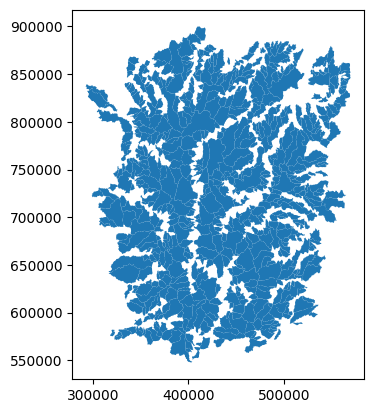

In [6]:
cat=catchments.to_crs(epsg=32618)
cat.rename(columns={"_mean":"rainfall_cat"}, inplace=True)
cat.plot()
cat.head(2)

se importan los movimientos en masa relictos

In [7]:
relict=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_rainfall.gpkg")
relict.head(2)

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,SAMPLE_1,geometry
0,El Guasimo,NaN,NaN,NaN,NaN,NaN,-1,0,-1,NaN,NaN,1841.776395,POINT Z (-75.86709 6.80850 753.10776)
1,El Noral,NaN,NaN,NaN,NaN,NaN,-1,0,-1,NaN,NaN,1946.703969,POINT Z (-75.50832 6.36266 1592.60560)


Se eliminan las columnas que no se van a utilizar y se cambia el nombre de la columna que tiene la lluvia. Y se proyecta a coordenadas planas.

,rainfall_rel,geometry
0,1841.776395,POINT Z (404187.110 752665.590 753.108)
1,1946.703969,POINT Z (443782.345 703321.444 1592.606)


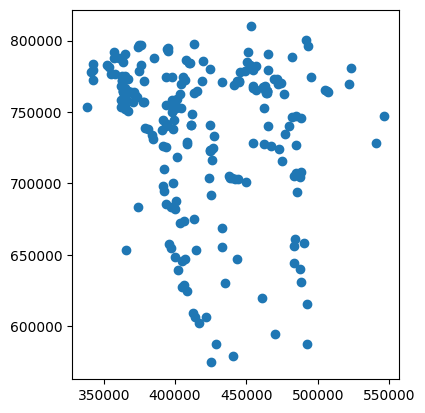

In [8]:
rel=relict.drop(["Name","descriptio","timestamp","begin","end","altitudeMo","tessellate","extrude","visibility","drawOrder","icon"],axis=1)
rel.rename(columns={"SAMPLE_1":"rainfall_rel"}, inplace=True)
rel=rel.to_crs(epsg=32618)
rel.plot()
rel.head(2)

Se realiza una interseccion espacial entre las cuencas 'cat' y los movimientos en masa recientes 'rec'

In [9]:
rel_cat = gpd.sjoin(rel, cat, how="inner")
rel_cat.head()

,rainfall_rel,geometry,index_right,OBJECTID,Área,hypso_inte,Nombre,Densidad,rainfall_cat,knickpoint
3,1871.538219,POINT Z (397878.994 758139.395 2042.377),340,349,132.670906,0.557,Quebrada Las Cuatro,16.356261,1918.178189,B
4,1871.538219,POINT Z (400192.726 757568.355 1528.623),340,349,132.670906,0.557,Quebrada Las Cuatro,16.356261,1918.178189,B
5,1871.538219,POINT Z (400200.925 758236.429 1295.065),340,349,132.670906,0.557,Quebrada Las Cuatro,16.356261,1918.178189,B
6,1871.538219,POINT Z (399820.479 757537.928 1477.209),340,349,132.670906,0.557,Quebrada Las Cuatro,16.356261,1918.178189,B
95,1917.651009,POINT Z (403187.874 762701.249 2101.139),340,349,132.670906,0.557,Quebrada Las Cuatro,16.356261,1918.178189,B


se agrupa por el numero de la cuenca para saber cuantos movimientso en masa hay por cuenca y se crea una dataframe.

In [10]:
rel_by_cat=rel_cat.groupby("Nombre").size()
land_cat=pd.DataFrame({"rel_count": rel_by_cat})
land_cat.head(2)

,rel_count
Nombre,
Quebrada Atenal,1
Quebrada Azulita,1


Se realiza un joint (no espacial) entre las cuencas 'cat' y el dataframe con el numero de movimientos en masa por cuenca 'land_cat', y se crea una nueva columna con la densidad de movimientos en masa. Donde no hay movimientos en masa aparece un NaN.

In [11]:
cat = cat.join(land_cat,on="Nombre")
cat["rel_density"] = cat["rel_count"]/cat["Área"]
cat.head(2)

,OBJECTID,Área,hypso_inte,Nombre,Densidad,rainfall_cat,knickpoint,geometry,rel_count,rel_density
0,1,120.181924,0.107,Quebrada Los San Andreses,2.446291,2250.332866,E,"MULTIPOLYGON (((411860.438 900002.542, 411964....",NaN,NaN
1,2,33.492364,0.334,Quebrada Sabalito,0.000000,3457.470653,A,"MULTIPOLYGON (((505464.576 881616.272, 505673....",NaN,NaN


Se crean nuevas columnas para el numero de movimientos en masa y para hipsometria para solo las cuencas con movimientso en masa y para solo las ceuncas sin movimientos en masa, para poder graficar mejor.

In [12]:
cat["rel_count"]=cat["rel_count"].fillna(0) #column with all catchments (with and without landslides)
cat["rel_count_landcat"]=cat["rel_count"].replace(0,np.nan) #column with only catchments with landslides
cat["rel_count_Nolandcat"]=np.where(cat["rel_count"]>0,np.nan,cat["rel_count"]) #column with only catchments without landslides
cat["hypso_landcat"]=np.where(cat["rel_count"]==0,np.nan,cat["hypso_inte"])
cat["hypso_Nolandcat"]=np.where(cat["rel_count"]>0,np.nan,cat["hypso_inte"])
cat['hypso_with']=cat['hypso_landcat'].fillna(0)
cat['hypso_without']=cat['hypso_Nolandcat'].fillna(0)
cat['landslides']=np.where(cat["rel_count"]>0,'Landslides','No lands.')
cat.head(2)

,OBJECTID,Área,hypso_inte,Nombre,Densidad,rainfall_cat,knickpoint,geometry,rel_count,rel_density,rel_count_landcat,rel_count_Nolandcat,hypso_landcat,hypso_Nolandcat,hypso_with,hypso_without,landslides
0,1,120.181924,0.107,Quebrada Los San Andreses,2.446291,2250.332866,E,"MULTIPOLYGON (((411860.438 900002.542, 411964....",0.0,NaN,NaN,0.0,NaN,0.107,0.0,0.107,No lands.
1,2,33.492364,0.334,Quebrada Sabalito,0.000000,3457.470653,A,"MULTIPOLYGON (((505464.576 881616.272, 505673....",0.0,NaN,NaN,0.0,NaN,0.334,0.0,0.334,No lands.


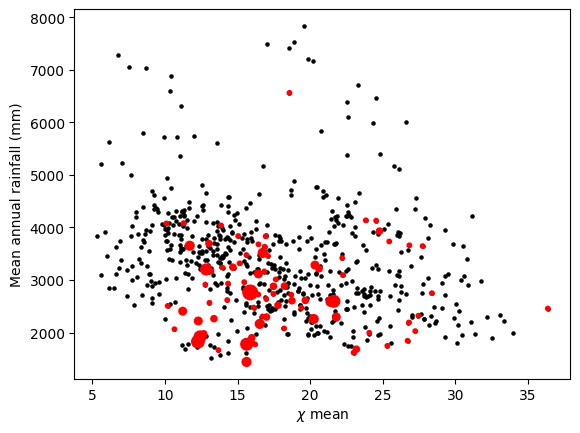

In [20]:
f, ax = plt.subplots()
ax.scatter(chi_cat["_chimean"],cat["rainfall_cat"],color='black',s=5)
ax.scatter(chi_cat["_chimean"],cat["rainfall_cat"],s=cat["rel_count"]*10,color='red')
ax.set_xlabel('$\chi$ mean')
ax.set_ylabel('Mean annual rainfall (mm)')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/chi_rainfall_relict.png")

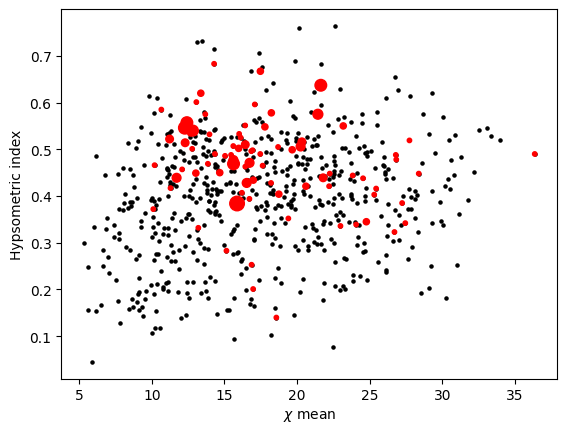

In [19]:
f, ax = plt.subplots()
ax.scatter(chi_cat["_chimean"],cat["hypso_inte"],color='black',s=5)
ax.scatter(chi_cat["_chimean"],cat["hypso_inte"],s=cat["rel_count"]*10,color='red')
ax.set_xlabel('$\chi$ mean')
ax.set_ylabel('Hypsometric index')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/chi_hypso_relict.png")

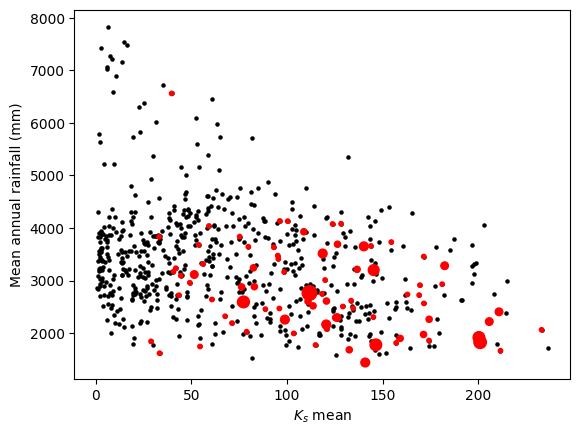

In [22]:
f, ax = plt.subplots()
ax.scatter(k_cat["_Ksmean"],cat["rainfall_cat"],color='black',s=5)
ax.scatter(k_cat["_Ksmean"],cat["rainfall_cat"],s=cat["rel_count"]*10,color='red')
ax.set_xlabel('$K_s$ mean')
ax.set_ylabel('Mean annual rainfall (mm)')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/Ks_rainfall_relict.png")

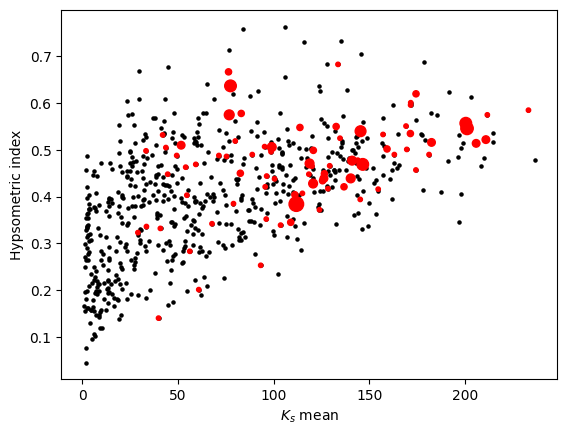

In [23]:
f, ax = plt.subplots()
ax.scatter(k_cat["_Ksmean"],cat["hypso_inte"],color='black',s=5)
ax.scatter(k_cat["_Ksmean"],cat["hypso_inte"],s=cat["rel_count"]*10,color='red')
ax.set_xlabel('$K_s$ mean')
ax.set_ylabel('Hypsometric index')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/Ks_hypso_relict.png")

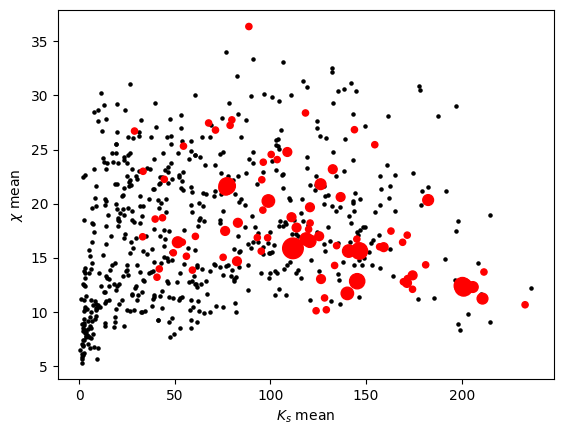

In [25]:
f, ax = plt.subplots()
ax.scatter(k_cat["_Ksmean"],chi_cat["_chimean"],color='black',s=5)
ax.scatter(k_cat["_Ksmean"],chi_cat["_chimean"],s=cat["rel_count"]*20,color='red')
ax.set_xlabel('$K_s$ mean')
ax.set_ylabel('$\chi$ mean')
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/Ks_chi_relict.png")

#### Numero de movimientos en masa vs. Indice hipsometrico

(0.0, 1.0)

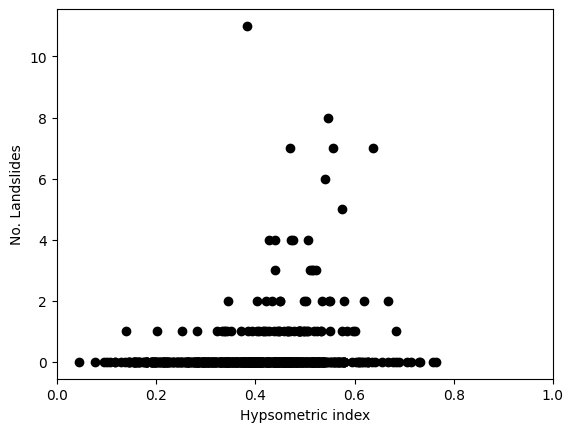

In [13]:
f, ax = plt.subplots()
ax.scatter(cat["hypso_inte"],cat["rel_count"],color="k")
ax.set_xlabel('Hypsometric index')
ax.set_ylabel('No. Landslides')
ax.set_xlim(0,1)
#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/relict_hypsoVSNoLandslides.png")

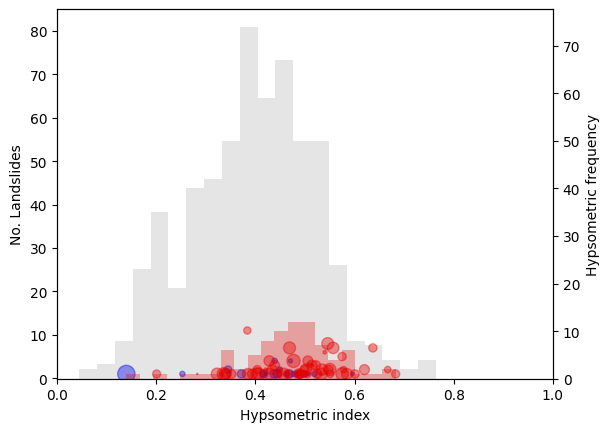

In [23]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax2.hist(cat["hypso_landcat"],bins=20,color="r",alpha=0.3,label="no landslides catchments")
ax2.hist(cat["hypso_Nolandcat"],bins=20,color="k",alpha=0.1,label="no landslides catchments")
ax.scatter(cat["hypso_inte"],cat["rel_count_landcat"],s=((cat["rainfall_cat"]-cat["rainfall_cat"].mean())/(cat["rainfall_cat"]).std())*50,color="b",alpha=0.4,label="Catchments with + rainfall anomalies")
ax.scatter(cat["hypso_inte"],cat["rel_count_landcat"],s=((cat["rainfall_cat"]-cat["rainfall_cat"].mean())/(cat["rainfall_cat"]).std())*-50,color="r",alpha=0.4,label="Catchments with - rainfall anomalies")
ax.set_xlabel('Hypsometric index')
ax.set_ylabel('No. Landslides')
ax2.set_ylabel('Hypsometric frequency')
ax.set_xlim(0,1)
ax.set_ylim(-0.1,85)
#ax.legend(ncol=1, loc='upper left',prop={'size': 14})
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/relict_hypsoVSNoLandslidesVsrainfall.png")

#### Lluvia vs. Indice hipsometrico

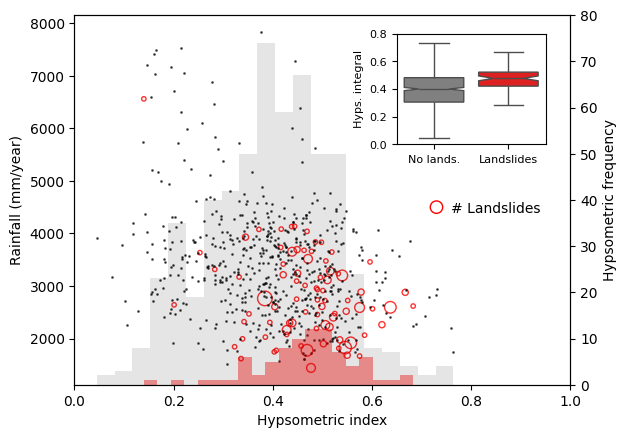

In [19]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax2.hist(cat["hypso_landcat"],bins=20,color="r",alpha=0.4,label="no landslides catchments")
ax2.hist(cat["hypso_Nolandcat"],bins=20,color="k",alpha=0.1,label="no landslides catchments")
ax.scatter(cat["hypso_landcat"],cat["rainfall_cat"],s=cat["rel_count"]*10,edgecolor='r',color='none',alpha=0.8)
ax.scatter(cat["hypso_Nolandcat"],cat["rainfall_cat"],s=1,color="k",alpha=0.6)
ax.set_xlabel('Hypsometric index')
ax.set_ylabel('Rainfall (mm/year)')
ax2.set_ylabel('Hypsometric frequency')
ax.set_xlim(0,1)
ax2.set_ylim(0,80)
ax.scatter([0.73],[4500],s=80,facecolor='none',edgecolors='red')
ax.text(0.76, 4400, '# Landslides',color='k',fontsize = 10) 

axin=ax.inset_axes([0.65,0.65,0.3,0.3])
sbn.boxplot(data=cat,x='landslides',y='hypso_inte',showfliers=False,hue='landslides',palette=['gray','red'],notch=True,linewidth=1,ax=axin)
axin.set_ylabel('Hyps. integral',size=8)
axin.set_xlabel('')
axin.set_yticks(np.arange(0,1,0.2))
axin.tick_params(axis='y', labelsize=8)
axin.tick_params(axis='x', labelsize=8)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/relict_hypsoVSrainfallVSlandslides.png")

#### Lluvia vs densidad estructural

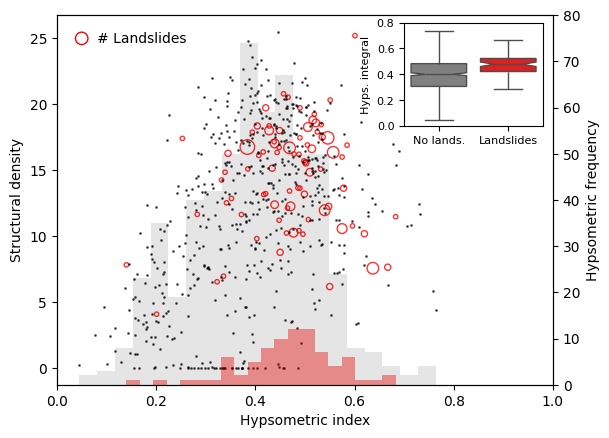

In [21]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax2.hist(cat["hypso_landcat"],bins=20,color="r",alpha=0.4,label="no landslides catchments")
ax2.hist(cat["hypso_Nolandcat"],bins=20,color="k",alpha=0.1,label="no landslides catchments")
ax.scatter(cat["hypso_landcat"],cat["Densidad"],s=cat["rel_count"]*10,edgecolor='r',color='none',alpha=0.8)
ax.scatter(cat["hypso_Nolandcat"],cat["Densidad"],s=1,color="k",alpha=0.6)
ax.set_xlabel('Hypsometric index')
ax.set_ylabel('Structural density')
ax2.set_ylabel('Hypsometric frequency')
ax.set_xlim(0,1)
ax2.set_ylim(0,80)
ax.scatter([0.05],[25],s=80,facecolor='none',edgecolors='red')
ax.text(0.08,24.7, '# Landslides',color='k',fontsize = 10) 

axin=ax.inset_axes([0.7,0.7,0.28,0.28])
sbn.boxplot(data=cat,x='landslides',y='hypso_inte',showfliers=False,hue='landslides',palette=['gray','red'],notch=True,linewidth=1,ax=axin)
axin.set_ylabel('Hyps. integral',size=8)
axin.set_xlabel('')
axin.set_yticks(np.arange(0,1,0.2))
axin.tick_params(axis='y', labelsize=8)
axin.tick_params(axis='x', labelsize=8)

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/relict_hypsoVSestructuralVSlandslides.png")

#### Mapa de hipsometria y movimientos en masa recientes con lluvia
Para graficar primero se deben obtener las coordenadas 'X' y 'Y' de lso movimientos en masa recientes y guardarlos en columnas en el dataframe.

In [24]:
rel["x"]=rel.centroid.x
rel["y"]=rel.centroid.y

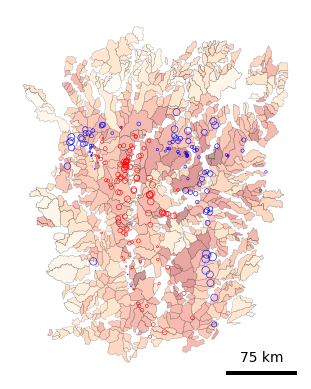

In [25]:
f, ax = plt.subplots()
cat.plot(column='hypso_inte',scheme='EqualInterval',ax=ax,cmap='OrRd',alpha=0.4,edgecolor='k',k=10, linewidth=0.2,legend=False)
rel.plot.scatter("x","y",linewidth=0.4,edgecolor='b',color='none',marker='.',s=((rel["rainfall_rel"]-rel["rainfall_rel"].mean())/(rel["rainfall_rel"].std()))*50,ax=ax)
rel.plot.scatter("x","y",linewidth=0.4,edgecolor='r',color='none',marker='.',s=((rel["rainfall_rel"]-rel["rainfall_rel"].mean())/(rel["rainfall_rel"].std()))*-50,ax=ax)
ax.set_axis_off()
scalebar = ScaleBar(1,"m",location="lower right",scale_loc="top",length_fraction=0.25)
ax.add_artist(scalebar);
plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/relict_map_hipsoVSlandslidesVsrainfall.png")